<h1 style="color:rgb(199, 12, 77);">Model Training and Evaluation</h1>

The purpose of this notebook is to train multiple regression models using the prepared Bitcoin dataset and compare their performance using regression evaluation metrics.

In [9]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import joblib
import os

In [2]:
# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Pipeline
from sklearn.pipeline import Pipeline

# Metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Model saving
import joblib

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [3]:
model_df = pd.read_csv("../data/processed/bitcoin_model_ready.csv")

In [4]:
model_df.head()

,Open,High,Low,Close,Volume,Volatility,Year,Return,MA_60,MA_240,...,Month,Hour,DayOfWeek,Next_Close,Log_Return,Close_Lag_1,Close_Lag_5,Close_Lag_15,Return_Lag_1,Volume_Lag_1
0,5.0,5.0,5.0,5.0,0.0,0.0,2012,0.0,5.0,5.0,...,1,10,0,5.0,0.0,5.0,5.0,5.0,0.0,0.0
1,5.0,5.0,5.0,5.0,0.0,0.0,2012,0.0,5.0,5.0,...,1,10,0,5.0,0.0,5.0,5.0,5.0,0.0,0.0
2,5.0,5.0,5.0,5.0,0.0,0.0,2012,0.0,5.0,5.0,...,1,10,0,5.0,0.0,5.0,5.0,5.0,0.0,0.0
3,5.0,5.0,5.0,5.0,0.0,0.0,2012,0.0,5.0,5.0,...,1,10,0,5.0,0.0,5.0,5.0,5.0,0.0,0.0
4,5.0,5.0,5.0,5.0,0.0,0.0,2012,0.0,5.0,5.0,...,1,10,0,5.0,0.0,5.0,5.0,5.0,0.0,0.0


In [5]:
split = int(len(model_df) * 0.8)

train = model_df.iloc[:split]

test = model_df.iloc[split:]

In [6]:
X_train = train.drop("Next_Close", axis=1)

X_test = test.drop("Next_Close", axis=1)

y_train = train["Next_Close"] 

y_test = test["Next_Close"]

In [7]:
models = {
    "Lineer Regression":Pipeline([
        ("scaler",StandardScaler()),
        ("Lineer Regression",LinearRegression())
    ]),

    "Ridge Regression":Pipeline([
        ("scaler",StandardScaler()),
        ("Ridge",Ridge(alpha=1))
    ]),

     "Lasso Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.001, max_iter=10000))
    ]),
    
    "ElasticNet Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000))
    ]),
}

In [8]:
results = []

for name, model in models.items():
    
    model.fit(X_train,y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    results.append({
        "Name: ":name,
        "R2 Score": r2,
        "MAE": mae,
        "RMSE": rmse}
    )

In [15]:
results_df = pd.DataFrame(results)

In [24]:
results_df = results_df.sort_values(by="R2 Score", ascending=False)
results_df.columns = ["Model","R2 Score","MAE","RMSE"]
results_df

,Model,R2 Score,MAE,RMSE
0,Lineer Regression,0.999997,29.398757,50.190280
1,Ridge Regression,0.999997,29.629914,50.549265
2,Lasso Regression,0.999994,39.256730,66.724251
3,ElasticNet Regression,0.999973,89.121451,142.557079


<h1 style="color:rgb(199, 12, 77);">Results:</h1>

All models achieved very high R2 scores. This is expected because the target variable is the next 1-minute closing price, and consecutive Bitcoin prices are usually very close to each other in high-frequency data.

Linear Regression produced the best overall performance with the highest R2 score and the lowest MAE and RMSE values.

Although the results are strong, this model should be interpreted as a short-horizon next-step prediction model rather than a long-term Bitcoin forecasting system.

In [11]:
for name, model in models.items():
    
    filename = f"../models/{name.replace(' ', '_')}.pkl"
    
    joblib.dump(model, filename)

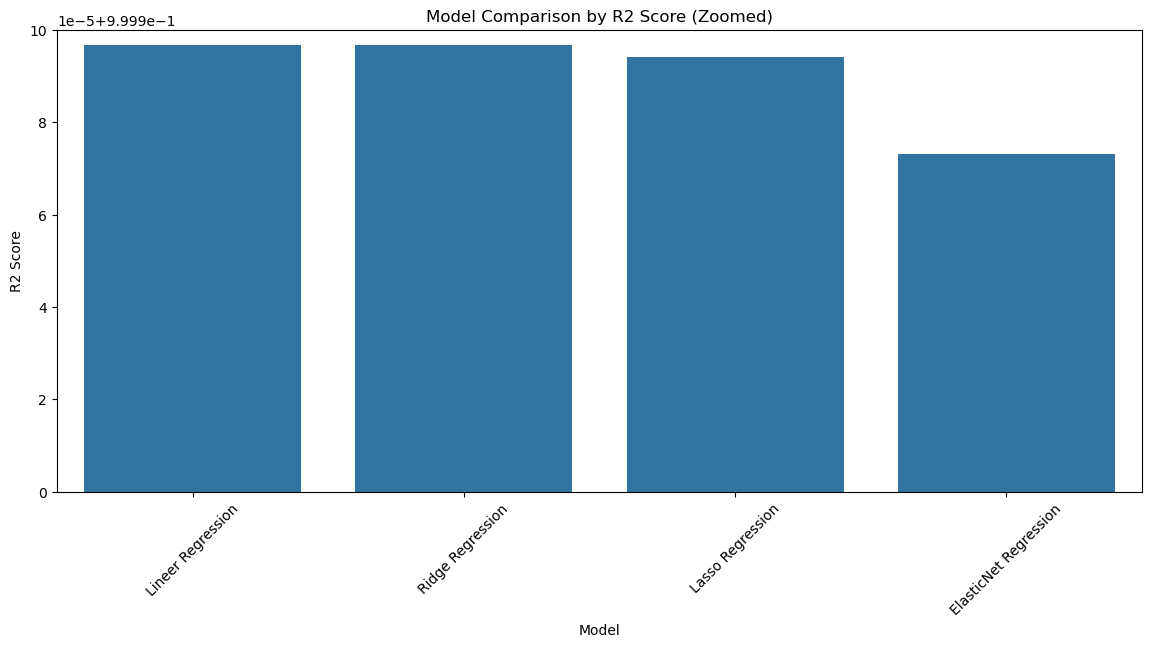

In [62]:
plt.figure(figsize=(14,6))
sns.barplot(data=results_df, x="Model", y="R2 Score")
plt.ylim(0.9999, 1.0000)  
plt.title("Model Comparison by R2 Score (Zoomed)")
plt.xticks(rotation=45)
plt.savefig("../outputs/figures/notebook4_figures/R2_model_comp")
plt.show()

> <h3 style="color:rgb(247, 147, 26)">Model Comparison by R2 Score</h3>

> This chart compares the regression models based on their R2 scores.

> All models achieved very high R2 values, which indicates that they explain most of the variation in the target variable.

> From a modeling perspective, this result is expected because the target variable is the next 1-minute closing price. In high-frequency financial data, consecutive prices are usually very close to each other, making short-horizon prediction easier than long-term forecasting.

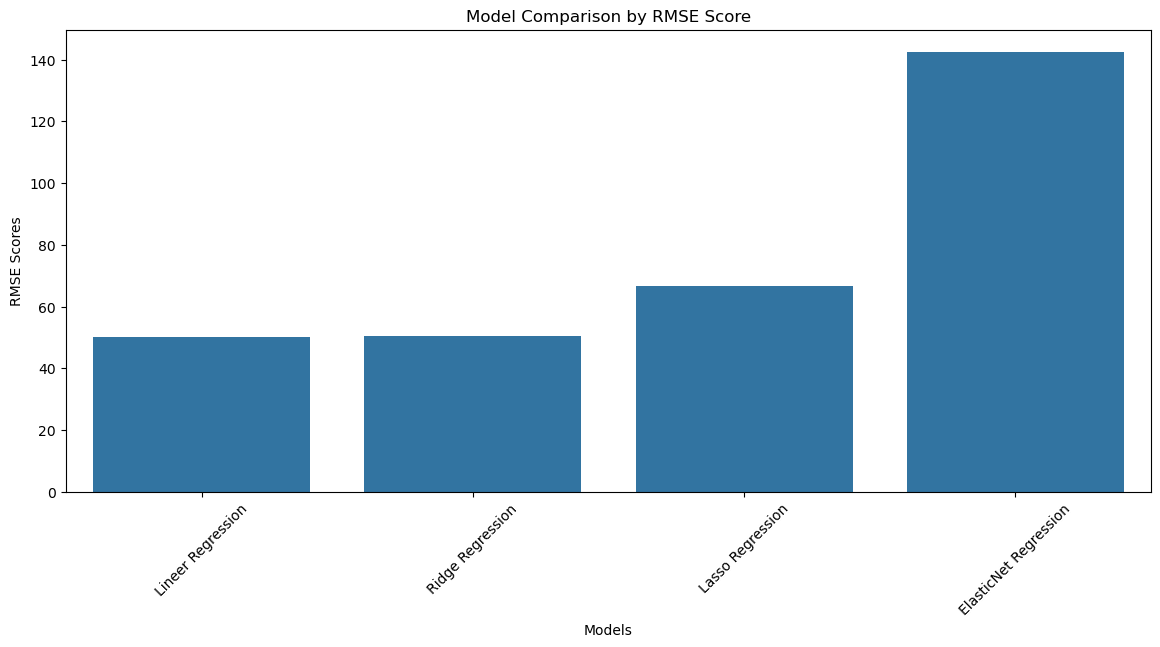

In [63]:
plt.figure(figsize=(14,6))
sns.barplot(data=results_df, x="Model", y="RMSE")
plt.xlabel("Models")
plt.ylabel("RMSE Scores")
plt.title("Model Comparison by RMSE Score")
plt.xticks(rotation=45)
plt.savefig("../outputs/figures/notebook4_figures/RMSE_model_comp")
plt.show()

> <h3 style="color:rgb(247, 147, 26)">Model Comparison by MAE</h3>

> This chart compares the models using Mean Absolute Error.

> MAE shows the average absolute difference between the actual and predicted Bitcoin closing prices.

> This metric is important because it gives a direct interpretation of model error in price units. A lower MAE means that the model's predictions are closer to the real next closing prices on average.

In [31]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
best_model_name

'Lineer Regression'

> <h3 style="color:rgb(247, 147, 26)">Best Model Selection</h3>

> The best-performing model was selected based on R2 Score, MAE, and RMSE values.

> Although all models performed strongly, the final model selection considers both prediction accuracy and error size.

> This is important because a high R2 score alone may not be enough for financial prediction tasks. MAE and RMSE provide more practical information about how large the prediction errors are in price terms.

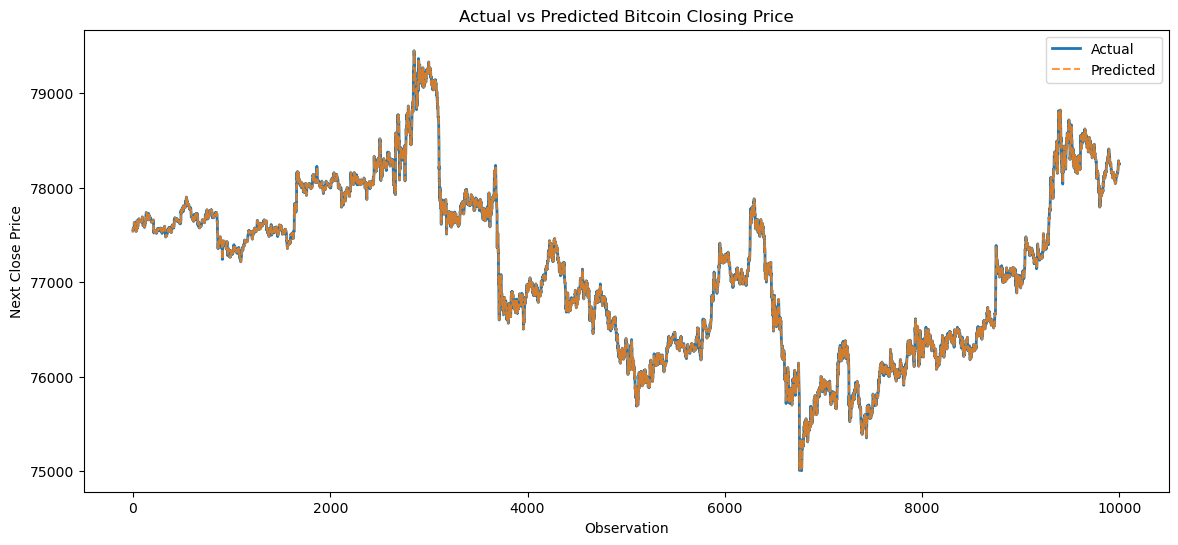

In [64]:
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

sample_df = comparison_df.tail(10_000)

plt.figure(figsize=(14,6))

plt.plot(
    sample_df["Actual"].values, 
    label="Actual", 
    linewidth=2)

plt.plot(
    sample_df["Predicted"].values, 
    label="Predicted", 
    linestyle="--", alpha=0.8)

plt.title("Actual vs Predicted Bitcoin Closing Price")
plt.xlabel("Observation")
plt.ylabel("Next Close Price")
plt.legend()
plt.savefig("../outputs/figures/notebook4_figures/Actual_vs_Predicted")
plt.show()

> <h3 style="color:rgb(247, 147, 26)">Actual vs Predicted Bitcoin Closing Price</h3>

> This chart compares the actual Bitcoin next closing prices with the predicted values generated by the best-performing model.

> The predicted line closely follows the actual line, showing that the model captures short-term price movements effectively.

> From a market perspective, this indicates that recent price behavior, lag features, moving averages, and volatility-based features provide useful information for predicting the next 1-minute closing price.

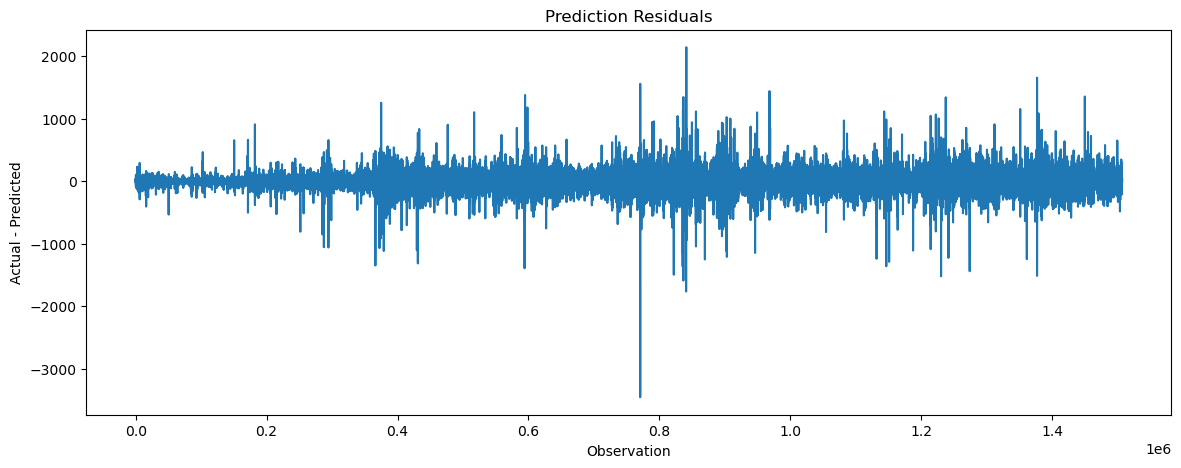

In [65]:
comparison_df["Residual"] = (
    comparison_df["Actual"] - comparison_df["Predicted"]
)

plt.figure(figsize=(14,5))
plt.plot(comparison_df["Residual"].values)

plt.title("Prediction Residuals")
plt.xlabel("Observation")
plt.ylabel("Actual - Predicted")
plt.savefig("../outputs/figures/notebook4_figures/Prediction Residuals")
plt.show()

> <h3 style="color:rgb(247, 147, 26)">Prediction Residuals</h3>

> This chart shows the residuals, which represent the difference between actual and predicted values.

> Residual analysis is important because it helps evaluate whether the model makes systematic errors or whether the errors are mostly random.

> In this project, smaller residual values indicate that the model predictions are generally close to the real Bitcoin prices, while larger residual spikes may represent sudden market movements that are harder to predict.

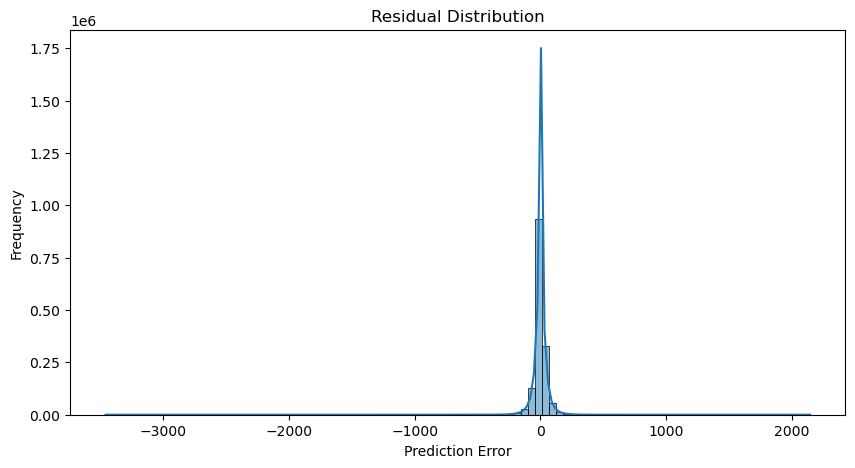

In [66]:
comparison_df["Residual"] = comparison_df["Actual"] - comparison_df["Predicted"]

plt.figure(figsize=(10,5))
sns.histplot(comparison_df["Residual"], bins=100, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.savefig("../outputs/figures/notebook4_figures/Residual Distribution")
plt.show()

> <h3 style="color:rgb(247, 147, 26)">Residual Distribution</h3>

> This distribution shows how prediction errors are spread around zero.

> A residual distribution concentrated near zero indicates that most model predictions are close to the actual values.

> From a financial modeling perspective, extreme residuals are expected because Bitcoin can experience sudden price movements due to volatility, liquidity changes, or unexpected market events.

In [56]:
sample_predictions = comparison_df.tail(10).copy()
sample_predictions["Absolute_Error"] = abs(sample_predictions["Actual"] - sample_predictions["Predicted"])
sample_predictions

,Actual,Predicted,Residual,Absolute_Error
1507030,78244.0,78249.451678,-5.451678,5.451678
1507031,78285.0,78242.990688,42.009312,42.009312
1507032,78275.0,78283.937514,-8.937514,8.937514
1507033,78258.0,78273.772739,-15.772739,15.772739
1507034,78250.0,78256.942162,-6.942162,6.942162
1507035,78251.0,78248.905639,2.094361,2.094361
1507036,78245.0,78249.671602,-4.671602,4.671602
1507037,78254.0,78243.937374,10.062626,10.062626
1507038,78256.0,78252.424924,3.575076,3.575076
1507039,78251.0,78254.338549,-3.338549,3.338549


> <h3 style="color:rgb(247, 147, 26)">Sample Prediction Results</h3>

> This table shows examples of actual and predicted Bitcoin closing prices.

> It provides a direct view of how close the model predictions are to the real target values.

> This is important because evaluation metrics summarize model performance, while prediction examples make the model's behavior easier to interpret.

In [57]:
results_df.to_csv("../outputs/reports/model_comparison.csv", index=False)
comparison_df.tail(10000).to_csv("../outputs/reports/prediction_examples.csv", index=False)

In [58]:
joblib.dump(best_model, f"../models/best_model_{best_model_name.replace(' ', '_')}.pkl")

['../models/best_model_Lineer_Regression.pkl']

> <h2 style="color:rgb(247, 147, 26)">Final Model Training Summary</h2>

> In this notebook, multiple regression models were trained and evaluated using the model-ready Bitcoin dataset.

> A time-based train-test split was used to preserve the chronological structure of the data and avoid data leakage.

> The models were evaluated using R2 Score, MAE, and RMSE. All models achieved strong performance, mainly because the prediction target is the next 1-minute Bitcoin closing price.

> The results show that engineered features such as lag values, moving averages, returns, and rolling volatility are useful for short-term Bitcoin price prediction.

> However, the model should be interpreted as a short-horizon forecasting model rather than a long-term Bitcoin price prediction system.

> Overall, the modeling process demonstrates that regression models can effectively capture short-term patterns in high-frequency Bitcoin market data.